In [1]:
import numpy as np
import py21cmfast as p21c
from astropy.cosmology import FlatLambdaCDM

# ------------------------------------------------------------------
# USER-DEFINED PARAMETERS (replace with your own values)
# ------------------------------------------------------------------
z_min      = 6.0          # final redshift of the light-cone
z_max      = 10.0         # highest redshift to integrate back to
Ndim       = 128          # HII_DIM
Lbox       = 300.0        # BOX_LEN (comoving Mpc)
n_cpus     = 8            # N_THREADS

# Cosmology
sigma_8   = 0.81
h         = 0.68
omega_0   = 0.31
omega_b   = 0.049
n_s       = 0.965

# Astrophysics
ioneff    = 30.0          # HII_EFF_FACTOR
mfp_ion   = 30.0          # R_BUBBLE_MAX (Mpc)
logLXray  = 40.0          # L_X (erg/s/Hz/SFR)

YHe       = 0.24          # helium mass fraction

# ------------------------------------------------------------------
# 1. Run the light-cone
# ------------------------------------------------------------------
lightcone = p21c.run_lightcone(
    lightcone_quantities=('velocity', 'density', 'xH_box'),
    redshift=z_min,
    max_redshift=z_max,
    cosmo_params=p21c.CosmoParams(
        SIGMA_8=sigma_8, hlittle=h, OMm=omega_0, OMb=omega_b, POWER_INDEX=n_s
    ),
    astro_params=p21c.AstroParams(
        {"HII_EFF_FACTOR": ioneff,
         "R_BUBBLE_MAX":  mfp_ion,
         "L_X":           logLXray}
    ),
    flag_options=p21c.FlagOptions({"USE_TS_FLUCT": True}),
    Y_He=YHe,
    user_params={
        "HII_DIM":               Ndim,
        "BOX_LEN":               Lbox,
        "USE_INTERPOLATION_TABLES": True,
        "N_THREADS":             n_cpus
    },
    random_seed=37,
    direc='_cache'
)

# ------------------------------------------------------------------
# 2. DIAGNOSTICS – confirm object structure
# ------------------------------------------------------------------
print("\n=== LIGHTCONE DIAGNOSTICS ===")
print("Attributes:", sorted(lightcone.__dict__.keys()))
print("Y_He (from global_params):", lightcone.global_params['Y_He'])

# ------------------------------------------------------------------
# 3. Light-cone geometry
# ------------------------------------------------------------------
pos_axis = lightcone.lightcone_distances          # comoving distance [Mpc]
red_axis = lightcone.lightcone_redshifts          # redshift per slice

# Trim to redshift <= z_max
ind_z = np.where(red_axis <= z_max)[0]
pos_axis = pos_axis[ind_z]
red_axis = red_axis[ind_z]

# ------------------------------------------------------------------
# 4. Extract fields
# ------------------------------------------------------------------
density      = lightcone.density[:, :, ind_z] + 1.0   # 1 + δ
xHI          = lightcone.xH_box[:, :, ind_z]        # neutral fraction
v_los_comov  = lightcone.velocity[:, :, ind_z]      # comoving Mpc s⁻¹

# ------------------------------------------------------------------
# 5. Convert velocity to physical km s⁻¹
# ------------------------------------------------------------------
Mpc_per_s_to_km_per_s = 3.08568e19
v_pec_km_s = v_los_comov * (1.0 + red_axis[None, None, :]) * Mpc_per_s_to_km_per_s

# ------------------------------------------------------------------
# 6. EXACT H(z) using astropy (Flat ΛCDM)
# ------------------------------------------------------------------
cosmo_astropy = FlatLambdaCDM(H0=100 * h, Om0=omega_0)  # H0 in km/s/Mpc, Om0 = Ω_m
H_z = cosmo_astropy.H(red_axis).value                    # H(z) in km s⁻¹ Mpc⁻¹

# Optional: Print H(z) evolution
print(f"\nH(z) evolution (z = {red_axis.min():.1f} → {red_axis.max():.1f}):")
print(f"   H({red_axis.min():.1f}) = {H_z[0]:.1f} km/s/Mpc")
print(f"   H({red_axis.max():.1f}) = {H_z[-1]:.1f} km/s/Mpc")




=== LIGHTCONE DIAGNOSTICS ===
Attributes: ['_current_index', '_current_redshift', 'astro_params', 'cache_files', 'cosmo_params', 'density', 'flag_options', 'global_brightness_temp', 'global_params', 'global_quantities', 'global_xH', 'lightcone_distances', 'lightcones', 'log10_mturnovers', 'log10_mturnovers_mini', 'node_redshifts', 'photon_nonconservation_data', 'random_seed', 'redshift', 'user_params', 'velocity', 'xH_box']
Y_He (from global_params): 0.24

H(z) evolution (z = 6.0 → 10.0):
   H(6.0) = 703.5 km/s/Mpc
   H(10.0) = 1380.5 km/s/Mpc


In [52]:
import py21cmfast as p21c

print("21cmFAST Version String:")
print(f"  Full version: {p21c.__version__}")
print(f"  Version type: {type(p21c.__version__)}")

# Parse the version string
version_str = p21c.__version__
print(f"\n  Raw string: '{version_str}'")

# Many Python packages use versions like: "3.1.5" or "3.1.5+git.abc1234"
# or for development: "3.1.5.dev123+gabc1234"

# Try to parse components
parts = version_str.split('+')
print(f"\n  Version parts (split by '+'):")
for i, part in enumerate(parts):
    print(f"    Part {i}: {part}")

# Check if there's git info in the version
if '+' in version_str:
    base_version = parts[0]
    extra_info = parts[1] if len(parts) > 1 else ""
    print(f"\n  Base version: {base_version}")
    print(f"  Extra info: {extra_info}")
    
    # Git hash is usually after 'g' in version strings
    if 'g' in extra_info:
        git_parts = extra_info.split('g')
        if len(git_parts) > 1:
            git_hash = git_parts[1].split('.')[0]
            print(f"  Git commit (from version): {git_hash}")

# Check for all version-related attributes
print("\n" + "="*60)
print("All version-related attributes in py21cmfast:")
for attr in sorted(dir(p21c)):
    if any(x in attr.lower() for x in ['version', 'git', 'commit', 'hash', 'rev']):
        try:
            val = getattr(p21c, attr)
            if not callable(val):
                print(f"  {attr}: {val}")
        except:
            pass

# Also check the __version__ more carefully
print("\n" + "="*60)
print("Detailed version breakdown:")
print(f"  {p21c.__version__}")
print(f"  Length: {len(p21c.__version__)} characters")
print(f"  Character breakdown: {[c for c in p21c.__version__]}")

21cmFAST Version String:
  Full version: 3.4.0
  Version type: <class 'str'>

  Raw string: '3.4.0'

  Version parts (split by '+'):
    Part 0: 3.4.0

All version-related attributes in py21cmfast:
  __version__: 3.4.0
  _version: <module 'py21cmfast._version' from '/home/swanith/.local/lib/python3.10/site-packages/py21cmfast/_version.py'>

Detailed version breakdown:
  3.4.0
  Length: 5 characters
  Character breakdown: ['3', '.', '4', '.', '0']


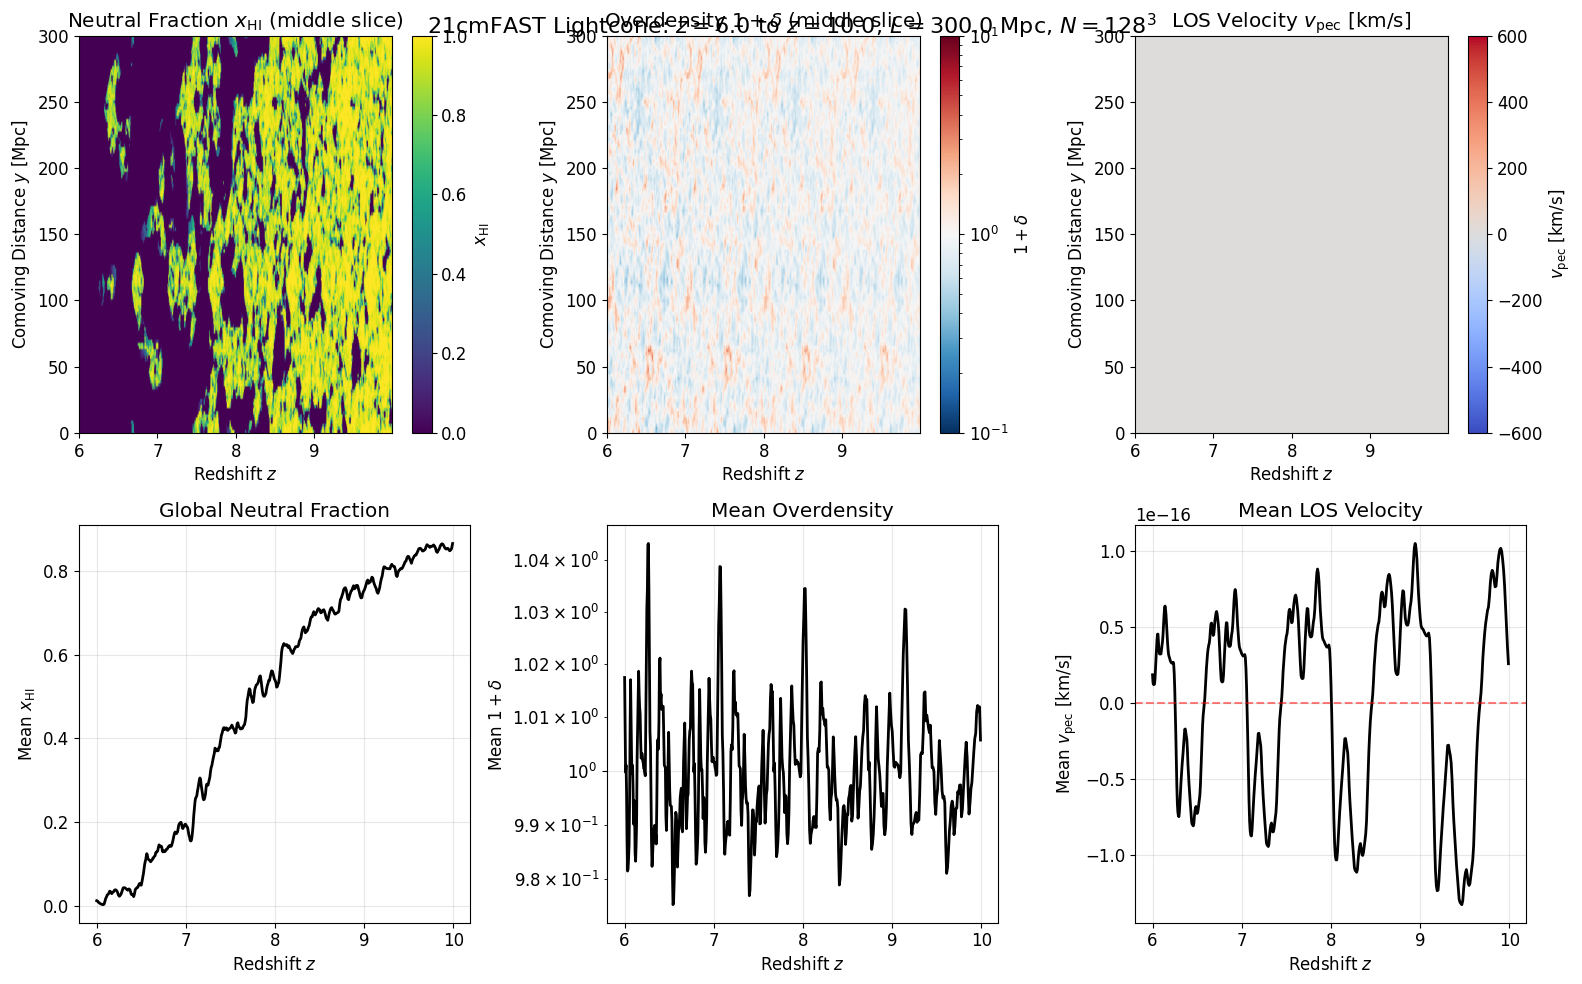

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm
import py21cmfast as p21c
from astropy.cosmology import FlatLambdaCDM

# ------------------------------------------------------------------
# (Assume lightcone is already run — insert your run_lightcone block here)
# ------------------------------------------------------------------

# For reproducibility — paste your full run_lightcone block above if needed

# ------------------------------------------------------------------
# 1. Extract and trim (same as before)
# ------------------------------------------------------------------
pos_axis = lightcone.lightcone_distances
red_axis = lightcone.lightcone_redshifts

ind_z = np.where(red_axis <= z_max)[0]
pos_axis = pos_axis[ind_z]
red_axis = red_axis[ind_z]

density = lightcone.density[:, :, ind_z] + 1.0
xHI     = lightcone.xH_box[:, :, ind_z]
v_los   = lightcone.velocity[:, :, ind_z]

# Physical velocity
Mpc_per_s_to_km_per_s = 3.08568e19
v_pec_km_s = v_los * (1.0 + red_axis[None, None, :]) * Mpc_per_s_to_km_per_s

# ------------------------------------------------------------------
# 2. Set up figure
# ------------------------------------------------------------------
plt.rcParams.update({'font.size': 12})
fig = plt.figure(figsize=(16, 10))

# ------------------------------------------------------------------
# 3. 2D Lightcone Slices (middle slice in transverse direction)
# ------------------------------------------------------------------
mid = Ndim // 2  # middle pixel in x and y

# --- Neutral Fraction xHI ---
ax1 = plt.subplot(2, 3, 1)
im1 = ax1.imshow(xHI[mid, :, :], aspect='auto', origin='lower',
                 extent=[red_axis.min(), red_axis.max(), 0, Lbox],
                 cmap='viridis', norm=Normalize(vmin=0, vmax=1))
ax1.set_xlabel('Redshift $z$')
ax1.set_ylabel('Comoving Distance $y$ [Mpc]')
ax1.set_title('Neutral Fraction $x_{\\mathrm{HI}}$ (middle slice)')
plt.colorbar(im1, ax=ax1, label='$x_{\\mathrm{HI}}$')

# --- Overdensity 1 + δ ---
ax2 = plt.subplot(2, 3, 2)
im2 = ax2.imshow(density[mid, :, :], aspect='auto', origin='lower',
                 extent=[red_axis.min(), red_axis.max(), 0, Lbox],
                 cmap='RdBu_r', norm=LogNorm(vmin=0.1, vmax=10))
ax2.set_xlabel('Redshift $z$')
ax2.set_ylabel('Comoving Distance $y$ [Mpc]')
ax2.set_title('Overdensity $1 + \\delta$ (middle slice)')
plt.colorbar(im2, ax=ax2, label='$1 + \\delta$')

# --- Velocity v_pec ---
ax3 = plt.subplot(2, 3, 3)
vmin, vmax = np.percentile(v_pec_km_s, [1, 99])
im3 = ax3.imshow(v_pec_km_s[mid, :, :], aspect='auto', origin='lower',
                 extent=[red_axis.min(), red_axis.max(), 0, Lbox],
                 cmap='coolwarm', vmin=-600, vmax=600)
ax3.set_xlabel('Redshift $z$')
ax3.set_ylabel('Comoving Distance $y$ [Mpc]')
ax3.set_title('LOS Velocity $v_{\\mathrm{pec}}$ [km/s]')
plt.colorbar(im3, ax=ax3, label='$v_{\\mathrm{pec}}$ [km/s]')

# ------------------------------------------------------------------
# 4. 1D Profiles (average over transverse plane)
# ------------------------------------------------------------------
xHI_mean = xHI.mean(axis=(0, 1))
density_mean = density.mean(axis=(0, 1))
v_pec_mean = v_pec_km_s.mean(axis=(0, 1))

ax4 = plt.subplot(2, 3, 4)
ax4.plot(red_axis, xHI_mean, 'k-', lw=2)
ax4.set_xlabel('Redshift $z$')
ax4.set_ylabel('Mean $x_{\\mathrm{HI}}$')
ax4.set_title('Global Neutral Fraction')
ax4.grid(True, alpha=0.3)

ax5 = plt.subplot(2, 3, 5)
ax5.plot(red_axis, density_mean, 'k-', lw=2)
ax5.set_xlabel('Redshift $z$')
ax5.set_ylabel('Mean $1 + \\delta$')
ax5.set_title('Mean Overdensity')
ax5.set_yscale('log')
ax5.grid(True, alpha=0.3)

ax6 = plt.subplot(2, 3, 6)
ax6.plot(red_axis, v_pec_mean, 'k-', lw=2)
ax6.set_xlabel('Redshift $z$')
ax6.set_ylabel('Mean $v_{\\mathrm{pec}}$ [km/s]')
ax6.set_title('Mean LOS Velocity')
ax6.axhline(0, color='r', ls='--', alpha=0.5)
ax6.grid(True, alpha=0.3)

# ------------------------------------------------------------------
# 5. Final layout
# ------------------------------------------------------------------
plt.tight_layout()
plt.suptitle(f'21cmFAST Lightcone: $z={z_min}$ to $z={z_max}$, '
             f'$L={Lbox}$ Mpc, $N={Ndim}^3$', fontsize=16, y=0.98)
plt.show()

In [6]:
# ------------------------------------------------------------------
# 1. All attributes that the LightCone object actually has
# ------------------------------------------------------------------
print("\n=== ALL ATTRIBUTES OF THE LightCone OBJECT ===")
print(sorted(lightcone.__dict__.keys()))
print("Total number of attributes :", len(lightcone.__dict__))

# ------------------------------------------------------------------
# 2. Parameter objects that are stored **as attributes**
# ------------------------------------------------------------------
print("\n=== PARAMETER OBJECTS (attributes) ===")
for name in ['cosmo_params', 'astro_params', 'flag_options', 'user_params']:
    obj = getattr(lightcone, name, None)
    print(f"{name:12s} : {obj}")

# ------------------------------------------------------------------
# 3. Y_He lives inside global_params (not as a top-level attribute)
# ------------------------------------------------------------------
print("\n=== GLOBAL PARAMETERS (including Y_He) ===")
global_params = lightcone.global_params
print("global_params is a dict with", len(global_params), "entries")
print("Y_He :", global_params['Y_He'])          # <-- this is the one you were missing

# ------------------------------------------------------------------
# 4. Light-cone fields that were requested & returned
# ------------------------------------------------------------------
print("\n=== LIGHT-CONE FIELDS THAT WERE REQUESTED & RETURNED ===")
requested = ('velocity', 'density', 'xH_box')
for name in requested:
    arr = getattr(lightcone, name)
    print(f"  {name:12s} -> shape {arr.shape}  dtype {arr.dtype}")

# ------------------------------------------------------------------
# 5. All *possible* light-cone quantities (for reference)
# ------------------------------------------------------------------
print("\n=== ALL POSSIBLE LIGHT-CONE QUANTITIES (from py21cmfast) ===")
possible = [
    'brightness_temp', 'density', 'velocity', 'xH_box',
    'Tk_box', 'Ts_box', 'Gamma12_box', 'temp_kinetic_all_gas'
]
for q in possible:
    print(f"  {q:20s} {'present' if hasattr(lightcone, q) else 'absent'}")


=== ALL ATTRIBUTES OF THE LightCone OBJECT ===
['_current_index', '_current_redshift', 'astro_params', 'cache_files', 'cosmo_params', 'density', 'flag_options', 'global_brightness_temp', 'global_params', 'global_quantities', 'global_xH', 'lightcone_distances', 'lightcones', 'log10_mturnovers', 'log10_mturnovers_mini', 'node_redshifts', 'photon_nonconservation_data', 'random_seed', 'redshift', 'user_params', 'velocity', 'xH_box']
Total number of attributes : 22

=== PARAMETER OBJECTS (attributes) ===
cosmo_params : CosmoParams:
    OMb        : 0.049
    OMm        : 0.31
    POWER_INDEX: 0.965
    SIGMA_8    : 0.81
    hlittle    : 0.68
    
astro_params : AstroParams:
    ALPHA_ESC       : -0.5
    ALPHA_STAR      : 0.5
    ALPHA_STAR_MINI : 0.5
    A_LW            : 2.0
    A_VCB           : 1.0
    BETA_LW         : 0.6
    BETA_VCB        : 1.8
    F_ESC10         : 0.1
    F_ESC7_MINI     : 0.01
    F_H2_SHIELD     : 0.0
    F_STAR10        : 0.05011872336272722
    F_STAR7_MINI 

In [ ]:
user_params = p21c.UserParams(
    HII_DIM=64, BOX_LEN=100, KEEP_3D_VELOCITIES=True
)

In [33]:
lcn = p21c.RectilinearLightconer.with_equal_cdist_slices(
    min_redshift=7.0,
    max_redshift=12.0,
    quantities=('brightness_temp', 'density', 'velocity_z', 'xH_box'),
    resolution=user_params.cell_size,
    # index_offset=0,
    get_los_velocity=True,  # Enable this if you want LOS velocity
)


In [34]:
lightcone = p21c.run_lightcone(
    lightconer=lcn,
    global_quantities=("brightness_temp", 'density', 'xH_box'),
    direc='_cache',
    user_params=user_params
)

/home/swanith/.local/lib/python3.10/site-packages/py21cmfast/inputs.py:515: UserWarning: The USE_INTERPOLATION_TABLES setting has changed in v3.1.2 to be default True. You can likely ignore this warning, but if you relied onhaving USE_INTERPOLATION_TABLES=False by *default*, please set it explicitly. To silence this warning, set it explicitly to True. Thiswarning will be removed in v4.
  warnings.warn(


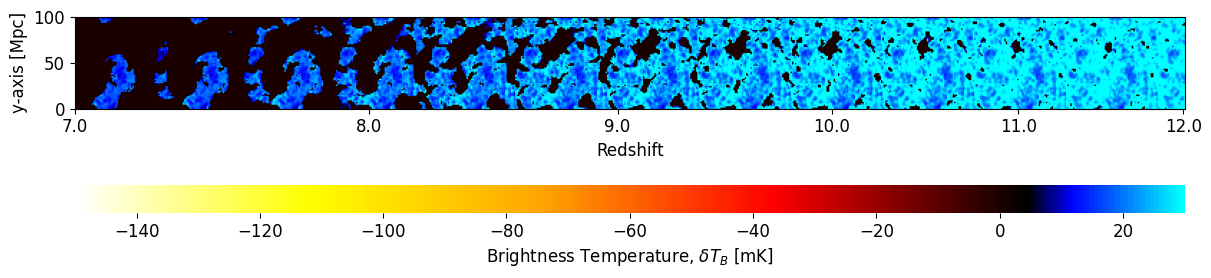

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plotting.lightcone_sliceplot(lightcone, ax=ax, fig=fig);



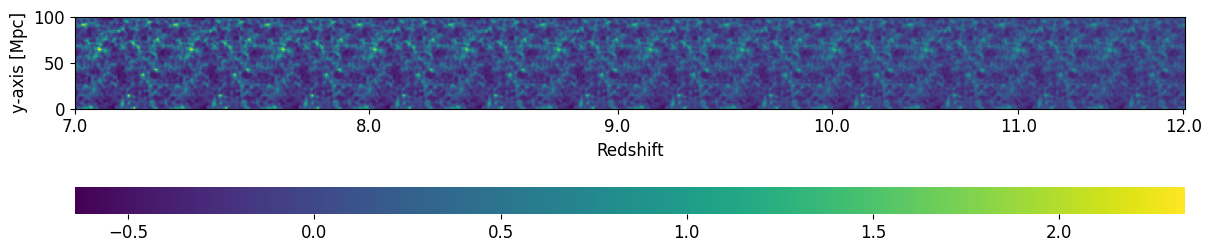

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plotting.lightcone_sliceplot(lightcone, 'density', ax=ax, fig=fig);

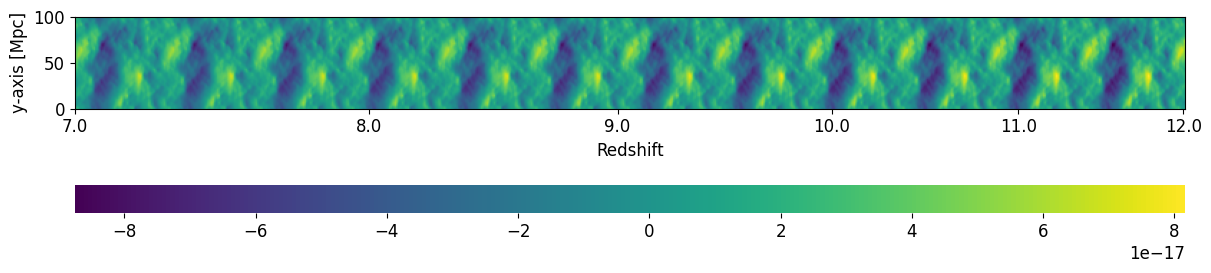

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plotting.lightcone_sliceplot(lightcone, 'velocity_z', ax=ax, fig=fig);

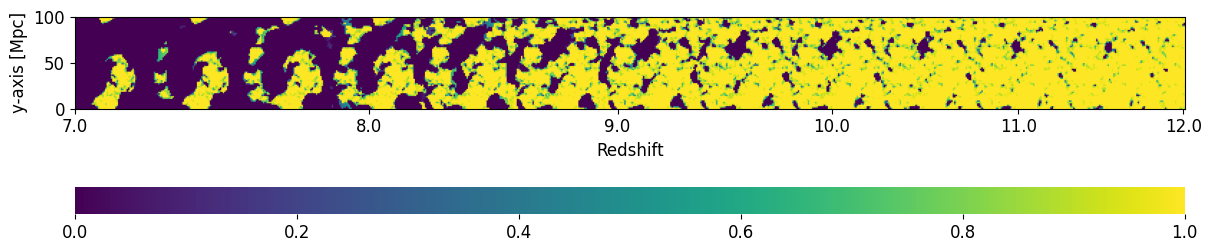

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plotting.lightcone_sliceplot(lightcone, 'xH_box', ax=ax, fig=fig);

Analyzing density at z = 12.00
Slice shape: (64, 64)


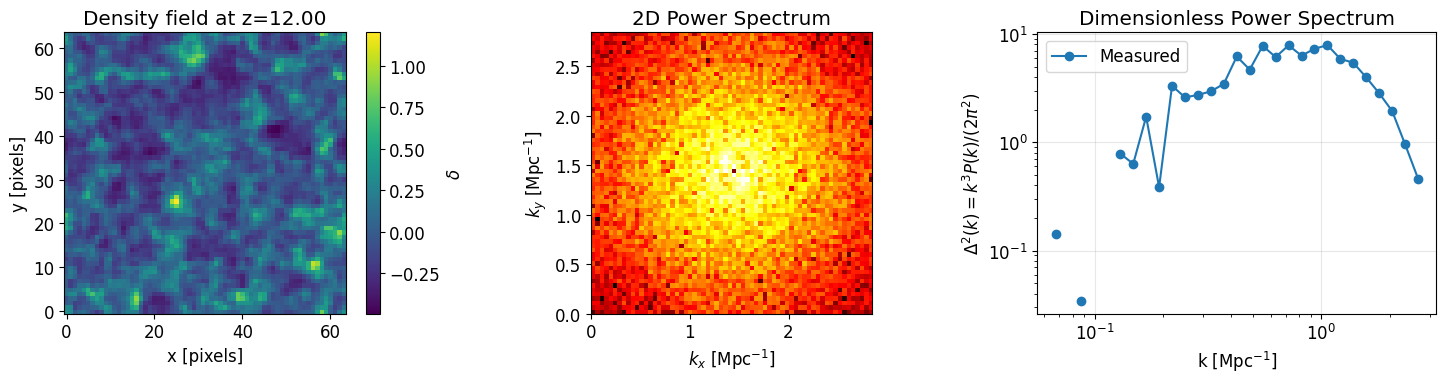

In [59]:
import matplotlib.pyplot as plt
from scipy import signal as sp_signal

# Get a 2D slice at a specific redshift index
z_idx = len(lcn.lc_redshifts)-1 #// 2  # middle redshift
z_slice = lcn.lc_redshifts[z_idx]

# Extract 2D slice of density field (perpendicular to LOS)
density_slice = lightcone.density[:, :, z_idx]  # shape: (N, N)

print(f"Analyzing density at z = {z_slice:.2f}")
print(f"Slice shape: {density_slice.shape}")

# Compute 2D power spectrum
def compute_2d_power_spectrum(field, box_size):
    """
    Compute 2D power spectrum from a 2D field.
    
    Parameters:
    -----------
    field : 2D array
        The density field
    box_size : float
        Physical size of the box in Mpc
    """
    N = field.shape[0]
    
    # 2D FFT
    field_k = np.fft.fft2(field)
    field_k = np.fft.fftshift(field_k)
    
    # Power spectrum
    power_2d = np.abs(field_k)**2
    
    # k-space coordinates
    k_fund = 2 * np.pi / box_size
    k_x = np.fft.fftshift(np.fft.fftfreq(N, d=1.0)) * N * k_fund
    k_y = np.fft.fftshift(np.fft.fftfreq(N, d=1.0)) * N * k_fund
    
    # Create 2D k-magnitude array
    kx_2d, ky_2d = np.meshgrid(k_x, k_y, indexing='ij')
    k_mag = np.sqrt(kx_2d**2 + ky_2d**2)
    
    return k_mag, power_2d

# Compute power spectrum
box_size = user_params.BOX_LEN  # in Mpc
k_mag, power_2d = compute_2d_power_spectrum(density_slice, box_size)

# Bin in radial k
k_bins = np.logspace(np.log10(k_mag[k_mag>0].min()), 
                     np.log10(k_mag.max()), 30)
k_centers = (k_bins[1:] + k_bins[:-1]) / 2

power_binned = []
for i in range(len(k_bins)-1):
    mask = (k_mag >= k_bins[i]) & (k_mag < k_bins[i+1]) & (k_mag > 0)
    if mask.sum() > 0:
        power_binned.append(power_2d[mask].mean())
    else:
        power_binned.append(np.nan)

power_binned = np.array(power_binned)

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Show the density slice
im = axes[0].imshow(density_slice, cmap='viridis', origin='lower')
axes[0].set_title(f'Density field at z={z_slice:.2f}')
axes[0].set_xlabel('x [pixels]')
axes[0].set_ylabel('y [pixels]')
plt.colorbar(im, ax=axes[0], label=r'$\delta$')

# 2. Show 2D power spectrum
axes[1].imshow(np.log10(power_2d), cmap='hot', origin='lower', 
               extent=[k_mag.min(), k_mag.max(), k_mag.min(), k_mag.max()])
axes[1].set_title('2D Power Spectrum')
axes[1].set_xlabel(r'$k_x$ [Mpc$^{-1}$]')
axes[1].set_ylabel(r'$k_y$ [Mpc$^{-1}$]')

# 3. Radially averaged power spectrum
axes[2].loglog(k_centers, power_binned * k_centers**3/ (2*np.pi**2), 
               'o-', label='Measured')

# Overplot linear theory (if you have it)
# from hmf import MassFunction
# or use CAMB/CLASS to get P(k) at this redshift
# axes[2].loglog(k_theory, P_theory, '--', label='Linear theory')

axes[2].set_xlabel(r'k [Mpc$^{-1}$]')
axes[2].set_ylabel(r'$\Delta^2(k) = k^3 P(k)/(2\pi^2)$')
axes[2].set_title('Dimensionless Power Spectrum')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('density_power_spectrum.png', dpi=150)
plt.show()

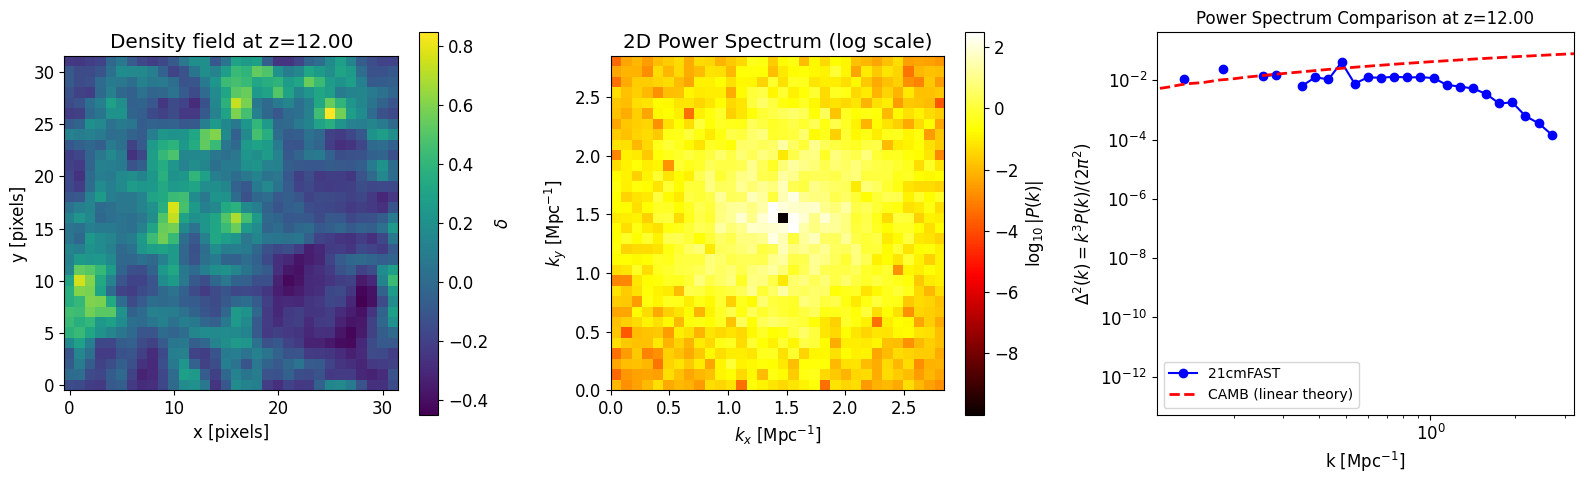


Power Spectrum Comparison at z=12.00:
21cmFAST k range: 0.1328 - 2.6985 Mpc^-1
CAMB k range: 0.0001 - 6.7660 Mpc^-1

At large scales (k~0.148 Mpc^-1):
  21cmFAST: Δ²(k) = nan
  CAMB:     Δ²(k) = 8.2163e-03
  Ratio:    nan


In [135]:
import camb
from camb import model
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.close('all')

# Set up CAMB with cosmology matching your 21cmFAST run
# (make sure these match your user_params cosmology!)
pars = camb.CAMBparams()

# Set cosmology - adjust these to match your 21cmFAST parameters
pars.set_cosmology(
    H0=67.66,  # Planck 2018 default in 21cmFAST
    ombh2=0.02242,  # Omega_b * h^2
    omch2=0.11933,  # Omega_c * h^2
    mnu=0.06,
    omk=0,
    tau=0.054
)

# Set initial power spectrum
pars.InitPower.set_params(As=2.1e-9, ns=0.9665)

# Set accuracy and matter power spectrum parameters
pars.set_matter_power(redshifts=[z_slice], kmax=10.0)

# Compute results
results = camb.get_results(pars)

# Get linear matter power spectrum at your redshift
kh_camb, z_camb, pk_camb = results.get_matter_power_spectrum(
    minkh=1e-4, maxkh=10, npoints=200
)

# Convert k from h/Mpc to 1/Mpc (21cmFAST typically uses h=0.7 or similar)
h = pars.H0 / 100.0
k_camb = kh_camb * h  # Convert to Mpc^-1
pk_camb_z = pk_camb[0, :] / h**3  # Convert to Mpc^3

# Compute dimensionless power spectrum
Delta2_camb = pk_camb_z *k_camb**3/ (2 * np.pi**2)#*k_camb**3

# Now plot everything together
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Show the density slice
im = axes[0].imshow(density_slice, cmap='viridis', origin='lower')
axes[0].set_title(f'Density field at z={z_slice:.2f}')
axes[0].set_xlabel('x [pixels]')
axes[0].set_ylabel('y [pixels]')
plt.colorbar(im, ax=axes[0], label=r'$\delta$')

# 2. Show 2D power spectrum
k_extent = [k_mag.min(), k_mag.max(), k_mag.min(), k_mag.max()]
im2 = axes[1].imshow(np.log10(power_2d + 1e-10), cmap='hot', origin='lower', 
                     extent=k_extent)
axes[1].set_title('2D Power Spectrum (log scale)')
axes[1].set_xlabel(r'$k_x$ [Mpc$^{-1}$]')
axes[1].set_ylabel(r'$k_y$ [Mpc$^{-1}$]')
plt.colorbar(im2, ax=axes[1], label=r'$\log_{10}|P(k)|$')

# 3. Radially averaged power spectrum with CAMB comparison
# Your 21cmFAST power spectrum
Delta2_21cm = power_binned/ (2*np.pi**2)*k_centers**2 * box_size**2 / Ndim**3

axes[2].loglog(k_centers, Delta2_21cm, 'o-', 
               label='21cmFAST', color='blue', markersize=6)

# CAMB linear theory
axes[2].loglog(k_camb, Delta2_camb, '--', 
               label='CAMB (linear theory)', color='red', linewidth=2)

axes[2].set_xlabel(r'k [Mpc$^{-1}$]', fontsize=12)
axes[2].set_ylabel(r'$\Delta^2(k) = k^3 P(k)/(2\pi^2)$', fontsize=12)
axes[2].set_title(f'Power Spectrum Comparison at z={z_slice:.2f}', fontsize=12)
axes[2].legend(fontsize=10)
#axes[2].grid(True, alpha=0.3, which='both')
axes[2].set_xlim([k_centers[~np.isnan(Delta2_21cm)].min() * 0.8, 
                  k_centers[~np.isnan(Delta2_21cm)].max() * 1.2])

plt.tight_layout()
plt.savefig('density_vs_camb_power_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

# Print some diagnostics
print(f"\nPower Spectrum Comparison at z={z_slice:.2f}:")
print(f"21cmFAST k range: {k_centers[~np.isnan(Delta2_21cm)].min():.4f} - {k_centers[~np.isnan(Delta2_21cm)].max():.4f} Mpc^-1")
print(f"CAMB k range: {k_camb.min():.4f} - {k_camb.max():.4f} Mpc^-1")
print(f"\nAt large scales (k~{k_centers[1]:.3f} Mpc^-1):")
print(f"  21cmFAST: Δ²(k) = {Delta2_21cm[1]:.4e}")
idx_camb = np.argmin(np.abs(k_camb - k_centers[1]))
print(f"  CAMB:     Δ²(k) = {Delta2_camb[idx_camb]:.4e}")
print(f"  Ratio:    {Delta2_21cm[1]/Delta2_camb[idx_camb]:.3f}")

In [130]:
import matplotlib.pyplot as plt
import numpy as np

# Get a 2D slice at a specific redshift index
z_idx = len(lcn.lc_redshifts) - 1
z_slice = lcn.lc_redshifts[z_idx]

# Extract 2D slice of density field
density_slice = lightcone.density[:, :, z_idx]

print(f"Analyzing density at z = {z_slice:.2f}")
print(f"Slice shape: {density_slice.shape}")

# Compute 2D power spectrum
def compute_2d_power_spectrum_with_errors(field, box_size):
    """
    Compute 2D power spectrum from a 2D field with error estimates.
    
    Parameters:
    -----------
    field : 2D array
        The density field
    box_size : float
        Physical size of the box in Mpc
    
    Returns:
    --------
    k_mag : 2D array
        k-magnitude at each point in k-space
    power_2d : 2D array
        Power spectrum at each point
    """
    N = field.shape[0]
    
    # Remove mean
    field_centered = field - field.mean()
    
    # 2D FFT
    field_k = np.fft.fft2(field_centered)
    field_k = np.fft.fftshift(field_k)
    
    # Power spectrum with normalization
    # Using the L²/N³ normalization we discussed
    power_2d = np.abs(field_k)**2 * box_size**2 / N**3
    
    # k-space coordinates
    k_fund = 2 * np.pi / box_size
    k_x = np.fft.fftshift(np.fft.fftfreq(N, d=1.0)) * N * k_fund
    k_y = np.fft.fftshift(np.fft.fftfreq(N, d=1.0)) * N * k_fund
    
    # Create 2D k-magnitude array
    kx_2d, ky_2d = np.meshgrid(k_x, k_y, indexing='ij')
    k_mag = np.sqrt(kx_2d**2 + ky_2d**2)
    
    return k_mag, power_2d

# Compute power spectrum
box_size = user_params.BOX_LEN  # in Mpc
Ndim = density_slice.shape[0]
k_mag, power_2d = compute_2d_power_spectrum_with_errors(density_slice, box_size)

# Bin in radial k WITH ERRORS
k_bins = np.logspace(np.log10(k_mag[k_mag>0].min()), 
                     np.log10(k_mag.max()), 30)
k_centers = (k_bins[1:] + k_bins[:-1]) / 2

power_binned = []
power_std = []
power_counts = []

for i in range(len(k_bins)-1):
    mask = (k_mag >= k_bins[i]) & (k_mag < k_bins[i+1]) & (k_mag > 0)
    n_modes = mask.sum()
    
    if n_modes > 0:
        powers_in_bin = power_2d[mask]
        power_binned.append(powers_in_bin.mean())
        power_std.append(powers_in_bin.std())  # Standard deviation
        power_counts.append(n_modes)
    else:
        power_binned.append(np.nan)
        power_std.append(np.nan)
        power_counts.append(0)

power_binned = np.array(power_binned)
power_std = np.array(power_std)
power_counts = np.array(power_counts)

# Standard error of the mean
power_sem = power_std / np.sqrt(power_counts)

# Compute dimensionless power spectrum
Delta2_21cm = power_binned * k_centers**3 / (2 * np.pi**2)
Delta2_std = power_std * k_centers**3 / (2 * np.pi**2)
Delta2_sem = power_sem * k_centers**3 / (2 * np.pi**2)

print(f"\nNumber of modes per bin:")
print(f"  Min: {power_counts[power_counts > 0].min()}")
print(f"  Max: {power_counts.max()}")
print(f"  Mean: {power_counts[power_counts > 0].mean():.1f}")

# Get CAMB prediction
import camb
from camb import model

pars = camb.CAMBparams()
pars.set_cosmology(
    H0=67.66,
    ombh2=0.02242,
    omch2=0.11933,
    mnu=0.06,
    omk=0,
    tau=0.054
)
pars.InitPower.set_params(As=2.1e-9, ns=0.9665)
pars.set_matter_power(redshifts=[z_slice], kmax=10.0)
results = camb.get_results(pars)

kh_camb, z_camb, pk_camb = results.get_matter_power_spectrum(
    minkh=1e-4, maxkh=10, npoints=200
)

h = pars.H0 / 100.0
k_camb = kh_camb * h
pk_camb_z = pk_camb[0, :] / h**3
Delta2_camb = pk_camb_z * k_camb**3 / (2 * np.pi)

# Plot with error bars
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Density slice
im = axes[0].imshow(density_slice, cmap='viridis', origin='lower')
axes[0].set_title(f'Density field at z={z_slice:.2f}')
axes[0].set_xlabel('x [pixels]')
axes[0].set_ylabel('y [pixels]')
plt.colorbar(im, ax=axes[0], label=r'$\delta$')

# 2. 2D power spectrum
axes[1].imshow(np.log10(power_2d + 1e-20), cmap='hot', origin='lower',
               extent=[k_mag.min(), k_mag.max(), k_mag.min(), k_mag.max()])
axes[1].set_title('2D Power Spectrum (log scale)')
axes[1].set_xlabel(r'$k_x$ [Mpc$^{-1}$]')
axes[1].set_ylabel(r'$k_y$ [Mpc$^{-1}$]')

axes[1].imshow(np.log10(power_2d + 1e-20), cmap='hot', origin='lower',
               extent=[k_mag.min(), k_mag.max(), k_mag.min(), k_mag.max()],
               vmin=-4, vmax=4)
plt.colorbar(im_middle, ax=axes[1], label=r'$\log_{10}|P(k)|$')

# 3. Radially averaged with error bars
# Plot with standard deviation as shaded region
valid = ~np.isnan(Delta2_21cm)
axes[2].loglog(k_camb, Delta2_camb, '--', 
               label='CAMB (linear theory)', color='red', linewidth=2)

# Plot 21cmFAST with error bars (showing ±1 std dev)
axes[2].fill_between(k_centers[valid], 
                      (Delta2_21cm - Delta2_std)[valid],
                      (Delta2_21cm + Delta2_std)[valid],
                      alpha=0.3, color='blue', label='21cmFAST ±1σ')

axes[2].loglog(k_centers[valid], Delta2_21cm[valid], 'o-', 
               label='21cmFAST', color='blue', markersize=6, linewidth=2)

# Also show standard error as error bars
axes[2].errorbar(k_centers[valid], Delta2_21cm[valid], 
                 yerr=Delta2_sem[valid],
                 fmt='none', ecolor='darkblue', alpha=0.5, capsize=3,
                 label='Standard error')

axes[2].set_xlabel(r'k [Mpc$^{-1}$]', fontsize=12)
axes[2].set_ylabel(r'$\Delta^2(k) = k^3 P(k)/(2\pi^2)$', fontsize=12)
axes[2].set_title(f'Power Spectrum Comparison at z={z_slice:.2f}', fontsize=12)
axes[2].legend(fontsize=10)
#axes[2].grid(True, alpha=0.3, which='both')
axes[2].set_xlim([k_centers[valid].min() * 0.8, 
                  k_centers[valid].max() * 1.2])


plt.tight_layout()
plt.savefig('density_power_spectrum_with_errors.png', dpi=150, bbox_inches='tight')
plt.show()

# Print diagnostics about deviations
print(f"\nDeviation analysis:")
for i, k_val in enumerate([0.2, 0.5, 1.0, 2.0]):
    idx_21cm = np.argmin(np.abs(k_centers - k_val))
    idx_camb = np.argmin(np.abs(k_camb - k_val))
    
    if not np.isnan(Delta2_21cm[idx_21cm]):
        ratio = Delta2_21cm[idx_21cm] / Delta2_camb[idx_camb]
        sigma_ratio = Delta2_std[idx_21cm] / Delta2_camb[idx_camb]
        n_sigma = (Delta2_21cm[idx_21cm] - Delta2_camb[idx_camb]) / Delta2_std[idx_21cm]
        
        print(f"\nAt k ≈ {k_val:.1f} Mpc⁻¹:")
        print(f"  21cmFAST: {Delta2_21cm[idx_21cm]:.4e} ± {Delta2_std[idx_21cm]:.4e}")
        print(f"  CAMB:     {Delta2_camb[idx_camb]:.4e}")
        print(f"  Ratio:    {ratio:.3f} ± {sigma_ratio:.3f}")
        print(f"  Deviation: {n_sigma:.2f}σ")
        print(f"  N_modes:  {power_counts[idx_21cm]}")

Analyzing density at z = 12.00
Slice shape: (32, 32)

Number of modes per bin:
  Min: 4
  Max: 158
  Mean: 42.6


/tmp/ipykernel_121800/3223163120.py:148: UserWarning: Adding colorbar to a different Figure <Figure size 1600x500 with 5 Axes> than <Figure size 1600x500 with 5 Axes> which fig.colorbar is called on.
  plt.colorbar(im_middle, ax=axes[1], label=r'$\log_{10}|P(k)|$')



Deviation analysis:

At k ≈ 0.5 Mpc⁻¹:
  21cmFAST: 2.6035e-01 ± 1.5512e-01
  CAMB:     8.3263e-02
  Ratio:    3.127 ± 1.863
  Deviation: 1.14σ
  N_modes:  4

At k ≈ 1.0 Mpc⁻¹:
  21cmFAST: 1.6222e-01 ± 1.1980e-01
  CAMB:     1.3461e-01
  Ratio:    1.205 ± 0.890
  Deviation: 0.23σ
  N_modes:  48

At k ≈ 2.0 Mpc⁻¹:
  21cmFAST: 4.6651e-02 ± 5.7149e-02
  CAMB:     1.9940e-01
  Ratio:    0.234 ± 0.287
  Deviation: -2.67σ
  N_modes:  158


/tmp/ipykernel_121800/3223163120.py:182: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [119]:
# Get the power spectrum from CAMB
kh_camb, z_camb, pk_camb = results.get_matter_power_spectrum(
    minkh=1e-4, maxkh=10, npoints=200
)

print("CAMB Output Units:")
print("="*60)
print(f"kh_camb: k in units of h/Mpc")
print(f"  Shape: {kh_camb.shape}")
print(f"  Range: {kh_camb.min():.6f} to {kh_camb.max():.3f} h/Mpc")
print(f"  First few values: {kh_camb[:5]}")

print(f"\npk_camb: P(k) in units of (Mpc/h)^3")
print(f"  Shape: {pk_camb.shape}")
print(f"  At z={z_camb[0]:.2f}")
print(f"  Range: {pk_camb[0].min():.3e} to {pk_camb[0].max():.3e} (Mpc/h)^3")
print(f"  First few values: {pk_camb[0,:5]}")

# Now let's convert properly
h = pars.H0 / 100.0
print(f"\nh parameter: {h:.6f}")

print("\n" + "="*60)
print("CONVERSION OPTIONS:")
print("="*60)

# Option 1: Convert k from h/Mpc to 1/Mpc
print("\nOption 1: Convert to Mpc^-1 and Mpc^3")
k_camb_opt1 = kh_camb * h  # h/Mpc * h = 1/Mpc
pk_camb_opt1 = pk_camb[0, :] / h**3  # (Mpc/h)^3 / h^3 = Mpc^3
print(f"  k: {k_camb_opt1[:3]} Mpc^-1")
print(f"  P(k): {pk_camb_opt1[:3]} Mpc^3")

# Option 2: Keep in h units (what 21cmFAST might use internally)
print("\nOption 2: Keep in h units")
k_camb_opt2 = kh_camb  # h/Mpc
pk_camb_opt2 = pk_camb[0, :]  # (Mpc/h)^3
print(f"  k: {k_camb_opt2[:3]} h/Mpc")
print(f"  P(k): {pk_camb_opt2[:3]} (Mpc/h)^3")

# Compute dimensionless power spectrum both ways
print("\n" + "="*60)
print("DIMENSIONLESS POWER SPECTRUM Δ²(k) = k³P(k)/(2π²):")
print("="*60)

Delta2_opt1 = k_camb_opt1**3 * pk_camb_opt1 / (2 * np.pi**2)
print(f"\nOption 1 (Mpc units):")
print(f"  Δ²(k) at k={k_camb_opt1[10]:.4f} Mpc^-1: {Delta2_opt1[10]:.6e}")

Delta2_opt2 = k_camb_opt2**3 * pk_camb_opt2 / (2 * np.pi**2)
print(f"\nOption 2 (h units):")
print(f"  Δ²(k) at k={k_camb_opt2[10]:.4f} h/Mpc: {Delta2_opt2[10]:.6e}")

print(f"\nThey should be equal (dimensionless): {np.allclose(Delta2_opt1, Delta2_opt2)}")

# Check what 21cmFAST uses
print("\n" + "="*60)
print("21cmFAST CONVENTION:")
print("="*60)
print(f"User params BOX_LEN: {user_params.BOX_LEN} Mpc")
print(f"Is this in comoving Mpc or Mpc/h?")
print("\nChecking 21cmFAST cosmology:")
if hasattr(user_params, 'POWER_SPECTRUM'):
    print(f"  POWER_SPECTRUM: {user_params.POWER_SPECTRUM}")

# The safe way: use dimensionless Δ²(k) which is independent of h
print("\n" + "="*60)
print("RECOMMENDATION: Use dimensionless Δ²(k)")
print("="*60)
print("This is independent of h convention!")


# What units is your measured k in?
print("\nYour measured k from 21cmFAST:")
print(f"  k_centers range: {k_centers[~np.isnan(k_centers)].min():.4f} to {k_centers[~np.isnan(k_centers)].max():.4f}")
print(f"  Based on BOX_LEN = {user_params.BOX_LEN} Mpc")
print(f"  Fundamental mode: 2π/{user_params.BOX_LEN} = {2*np.pi/user_params.BOX_LEN:.4f}")

# This tells us if 21cmFAST is using Mpc or Mpc/h
print("\nTo determine units: if BOX_LEN is in Mpc, then k is in Mpc^-1")
print("                    if BOX_LEN is in Mpc/h, then k is in h/Mpc")

CAMB Output Units:
kh_camb: k in units of h/Mpc
  Shape: (200,)
  Range: 0.000100 to 10.000 h/Mpc
  First few values: [0.0001     0.00010596 0.00011227 0.00011895 0.00012604]

pk_camb: P(k) in units of (Mpc/h)^3
  Shape: (1, 200)
  At z=12.00
  Range: 2.153e-03 to 2.380e+02 (Mpc/h)^3
  First few values: [4.03152145 4.26329877 4.50839206 4.76756511 5.0416245 ]

h parameter: 0.676600

CONVERSION OPTIONS:

Option 1: Convert to Mpc^-1 and Mpc^3
  k: [6.76600000e-05 7.16898417e-05 7.59597016e-05] Mpc^-1
  P(k): [13.01586377 13.7641624  14.55545199] Mpc^3

Option 2: Keep in h units
  k: [0.0001     0.00010596 0.00011227] h/Mpc
  P(k): [4.03152145 4.26329877 4.50839206] (Mpc/h)^3

DIMENSIONLESS POWER SPECTRUM Δ²(k) = k³P(k)/(2π²):

Option 1 (Mpc units):
  Δ²(k) at k=0.0001 Mpc^-1: 2.025914e-12

Option 2 (h units):
  Δ²(k) at k=0.0002 h/Mpc: 2.025914e-12

They should be equal (dimensionless): True

21cmFAST CONVENTION:
User params BOX_LEN: 256 Mpc
Is this in comoving Mpc or Mpc/h?

Checking 21

In [39]:
# Double-check z_slice matches what you passed to CAMB
print(f"Slice redshift: {z_slice}")
print(f"CAMB redshift: {z_camb}")

Slice redshift: 9.053000606618868
CAMB redshift: [9.053000606618868]


In [45]:
# Check your resolution
cell_size = user_params.BOX_LEN / user_params.DIM
nyquist_k = np.pi / cell_size

print(f"\nResolution:")
print(f"  Cell size: {cell_size:.3f} Mpc")
print(f"  Nyquist k: {nyquist_k:.3f} Mpc^-1")
print(f"  Your k range: {k_centers.min():.3f} - {k_centers.max():.3f} Mpc^-1")

# Are you above Nyquist? That would give spurious power


Resolution:
  Cell size: 0.521 Mpc
  Nyquist k: 6.032 Mpc^-1
  Your k range: 0.067 - 2.668 Mpc^-1


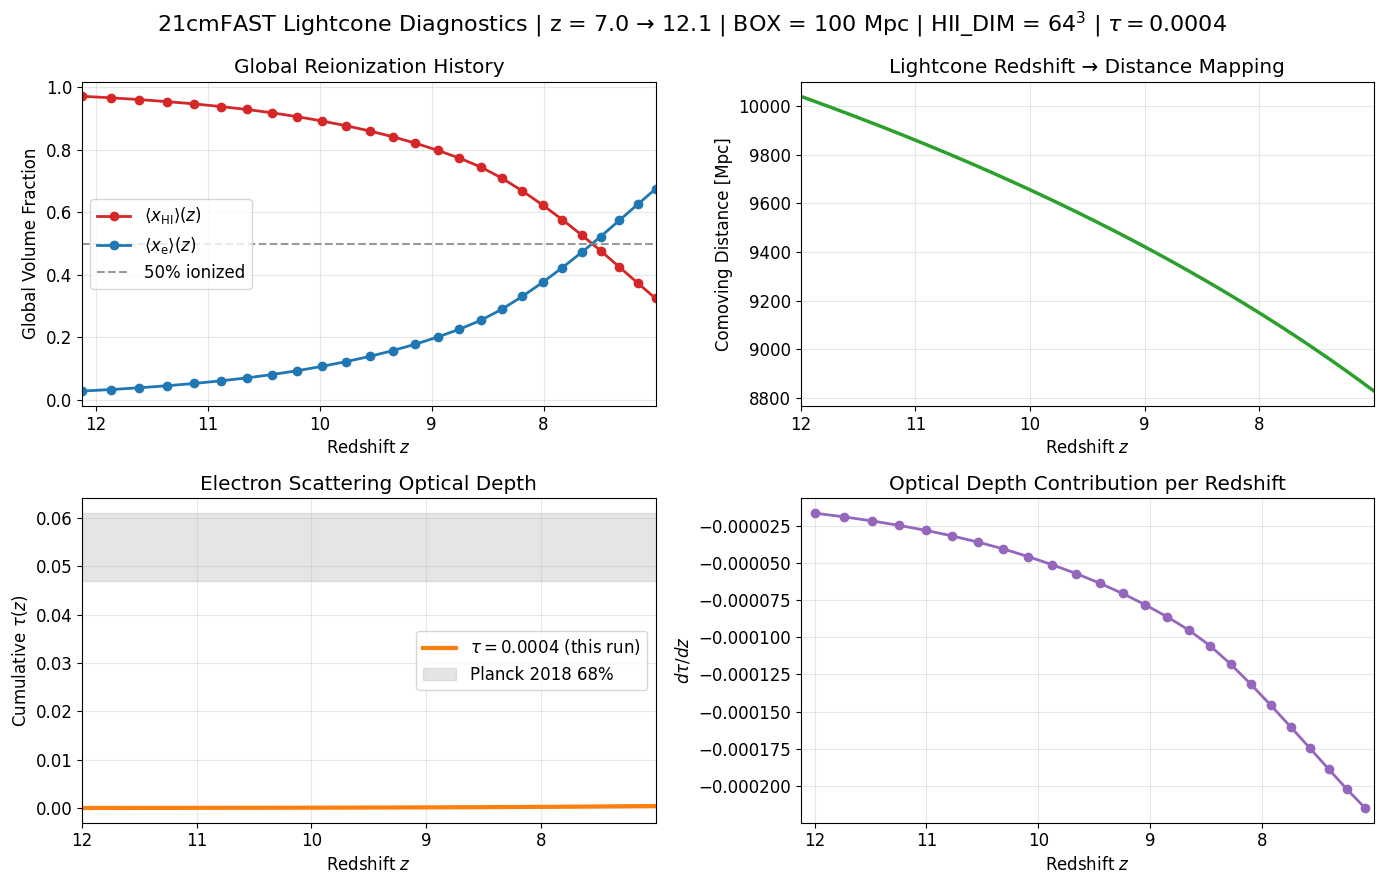

In [94]:
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM

# Build the exact same cosmology as your simulation
cosmo = FlatLambdaCDM(
    H0=100 * lightcone.cosmo_params.hlittle,   # km/s/Mpc
    Om0=lightcone.cosmo_params.OMm,
    Ob0=lightcone.cosmo_params.OMb,
    Tcmb0=2.7255*u.K,          # optional, but good
    Neff=3.046,
    m_nu=[0, 0, 0.06]*u.eV
)


# ------------------------------------------------------------------
# Cosmology from your lightcone
# ------------------------------------------------------------------
cosmo = FlatLambdaCDM(
    H0=100 * lightcone.cosmo_params.hlittle,
    Om0=lightcone.cosmo_params.OMm,
    Ob0=lightcone.cosmo_params.OMb
)

# ------------------------------------------------------------------
# GLOBAL quantities (coarse grid: node_redshifts)
# ------------------------------------------------------------------
z_global   = lightcone.node_redshifts          # shape ~ (26,)
xH_global  = lightcone.global_xH
xe_global  = 1.0 - xH_global
#chi_global = cosmo.comoving_distance(z_global).to(u.Mpc).value   # ← THIS IS GOLD     # fine grid ~ (774,)

# ------------------------------------------------------------------
# FINE lightcone grid (pixel-level)
# ------------------------------------------------------------------
z_fine     = lightcone.lightcone_redshifts     # shape = (774,) — this exists!
chi_global = cosmo.comoving_distance(z_fine).to(u.Mpc).value#chi_fine   = lightcone.lightcone_distances     # same as chi_global, but aligned

# ------------------------------------------------------------------
# Compute τ(z) on the coarse (global) grid — this is correct
# ------------------------------------------------------------------
sigma_T = const.sigma_T.cgs.value
m_p     = const.m_p.cgs.value
rho_c0  = cosmo.critical_density0.to(u.g/u.cm**3).value
n0      = (cosmo.Ob0 * rho_c0) / m_p
Mpc_cm  = 3.08568e24

order = np.argsort(-z_global)
z_s, xe_s, chi_s = z_global[order], xe_global[order], chi_global[order]

dchi = np.diff(chi_s)
dchi = np.insert(dchi, 0, 0.0)
z_mid = 0.5*(z_s[:-1] + z_s[1:])
a_mid = 1.0/(1.0 + z_mid)
xe_mid = 0.5*(xe_s[:-1] + xe_s[1:])

dtau = sigma_T * n0 * xe_mid * (a_mid**-2) * (dchi[1:] * Mpc_cm)
tau_global = np.cumsum(dtau)
tau_global = np.insert(tau_global, 0, 0.0)
tau_global = tau_global[np.argsort(order)]

# ------------------------------------------------------------------
# Plotting — now with correct arrays!
# ------------------------------------------------------------------
plt.figure(figsize=(14, 9))

# 1. Ionization history (coarse grid)
plt.subplot(2, 2, 1)
plt.plot(z_global, xH_global, 'C3-o', ms=6, lw=2, label=r'$\langle x_{\rm HI} \rangle(z)$')
plt.plot(z_global, xe_global, 'C0-o', ms=6, lw=2, label=r'$\langle x_{\rm e} \rangle(z)$')
plt.axhline(0.5, color='gray', ls='--', alpha=0.8, label='50% ionized')
plt.xlabel('Redshift $z$')
plt.ylabel('Global Volume Fraction')
plt.title('Global Reionization History')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(z_global.max(), z_global.min())

# 2. Lightcone geometry (fine grid)
plt.subplot(2, 2, 2)
plt.plot(z_fine, chi_global, 'C2-', lw=2.5)
plt.xlabel('Redshift $z$')
plt.ylabel('Comoving Distance [Mpc]')
plt.title('Lightcone Redshift → Distance Mapping')
plt.grid(alpha=0.3)
plt.xlim(z_fine.max(), z_fine.min())

# 3. Optical depth τ(z) — interpolated to fine grid for smooth plot
plt.subplot(2, 2, 3)
tau_fine = np.interp(z_fine[::-1], z_global[::-1], tau_global[::-1])[::-1]  # align & interp
plt.plot(z_fine, tau_fine, 'C1-', lw=3, label=rf'$\tau = {tau_global[-1]:.4f}$ (this run)')
plt.axhspan(0.047, 0.061, color='gray', alpha=0.2, label='Planck 2018 68%')
plt.xlabel('Redshift $z$')
plt.ylabel('Cumulative $\\tau(z)$')
plt.title('Electron Scattering Optical Depth')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(z_fine.max(), z_fine.min())

# 4. dτ/dz — where the optical depth comes from
plt.subplot(2, 2, 4)
dtau_dz = np.diff(tau_global) / np.diff(z_global)
z_dtau = 0.5*(z_global[:-1] + z_global[1:])
plt.plot(z_dtau, dtau_dz, 'C4-o', ms=6, lw=2)
plt.xlabel('Redshift $z$')
plt.ylabel('$d\\tau / dz$')
plt.title('Optical Depth Contribution per Redshift')
plt.grid(alpha=0.3)
plt.xlim(z_global.max(), z_global.min())

# Global title
plt.suptitle(f'21cmFAST Lightcone Diagnostics | '
             f'z = {lightcone.redshift:.1f} → {z_global.max():.1f} | '
             f'BOX = {lightcone.user_params.BOX_LEN:.0f} Mpc | '
             f'HII_DIM = {lightcone.user_params.HII_DIM}$^3$ | '
             f'$\\tau = {tau_global[-1]:.4f}$',
             fontsize=16, y=0.98)

plt.tight_layout()
plt.show()

kSZ signal in K:
  Mean: -2.1074e-05 K
  Std: 1.8649e-03 K
  Min: -3.4080e-02 K
  Max: 2.7294e-02 K
  RMS: 1.8650e-03 K


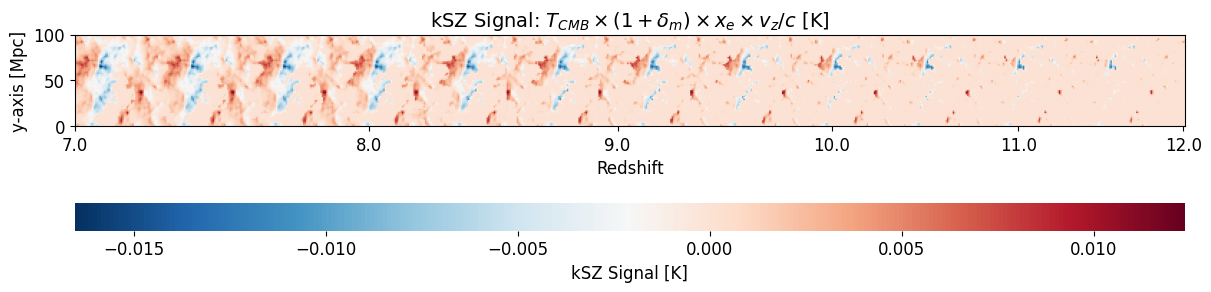

In [108]:
# Calculate kSZ in μK
T_CMB = 1#2.7255  # K (CMB temperature)
T_CMB_uK = 1#T_CMB * 1e6  # μK

kSZ_product = (1 + density) * x_e * v_los_km_s / c_km_s
kSZ_uK = kSZ_product * T_CMB_uK  # Convert to μK

print(f"kSZ signal in K:")
print(f"  Mean: {kSZ_uK.mean():.4e} K")
print(f"  Std: {kSZ_uK.std():.4e} K")
print(f"  Min: {kSZ_uK.min():.4e} K")
print(f"  Max: {kSZ_uK.max():.4e} K")
print(f"  RMS: {np.sqrt(np.mean(kSZ_uK**2)):.4e} K")

# Add it to the lightcone object
lightcone.kSZ_uK = kSZ_uK

# Plot it with red-blue colormap
fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)

# We need to manually set the colormap since lightcone_sliceplot has defaults
# Let's check what the function does and override if needed
from matplotlib import pyplot as plt

# Use the plotting function but we'll modify the colorbar label after
plotting.lightcone_sliceplot(lightcone, 'kSZ_uK', ax=ax, fig=fig)

# Update the colormap to RdBu_r (red-blue reversed, so red is positive)
# We need to access the image and update it
for child in ax.get_children():
    if hasattr(child, 'set_cmap'):
        child.set_cmap('RdBu_r')
        
# Update the colorbar label
cbar = fig.get_axes()[-1]  # The colorbar is typically the last axis
cbar.set_xlabel(r'kSZ Signal [K]', fontsize=12)

ax.set_title(r'kSZ Signal: $T_{CMB} \times (1+\delta_m) \times x_e \times v_z / c$ [K]', 
             fontsize=14)

plt.savefig('kSZ_signal_K.png', dpi=150, bbox_inches='tight')
plt.show()

Target redshift: 10.0
Closest slice: z = 10.001 (index 528)


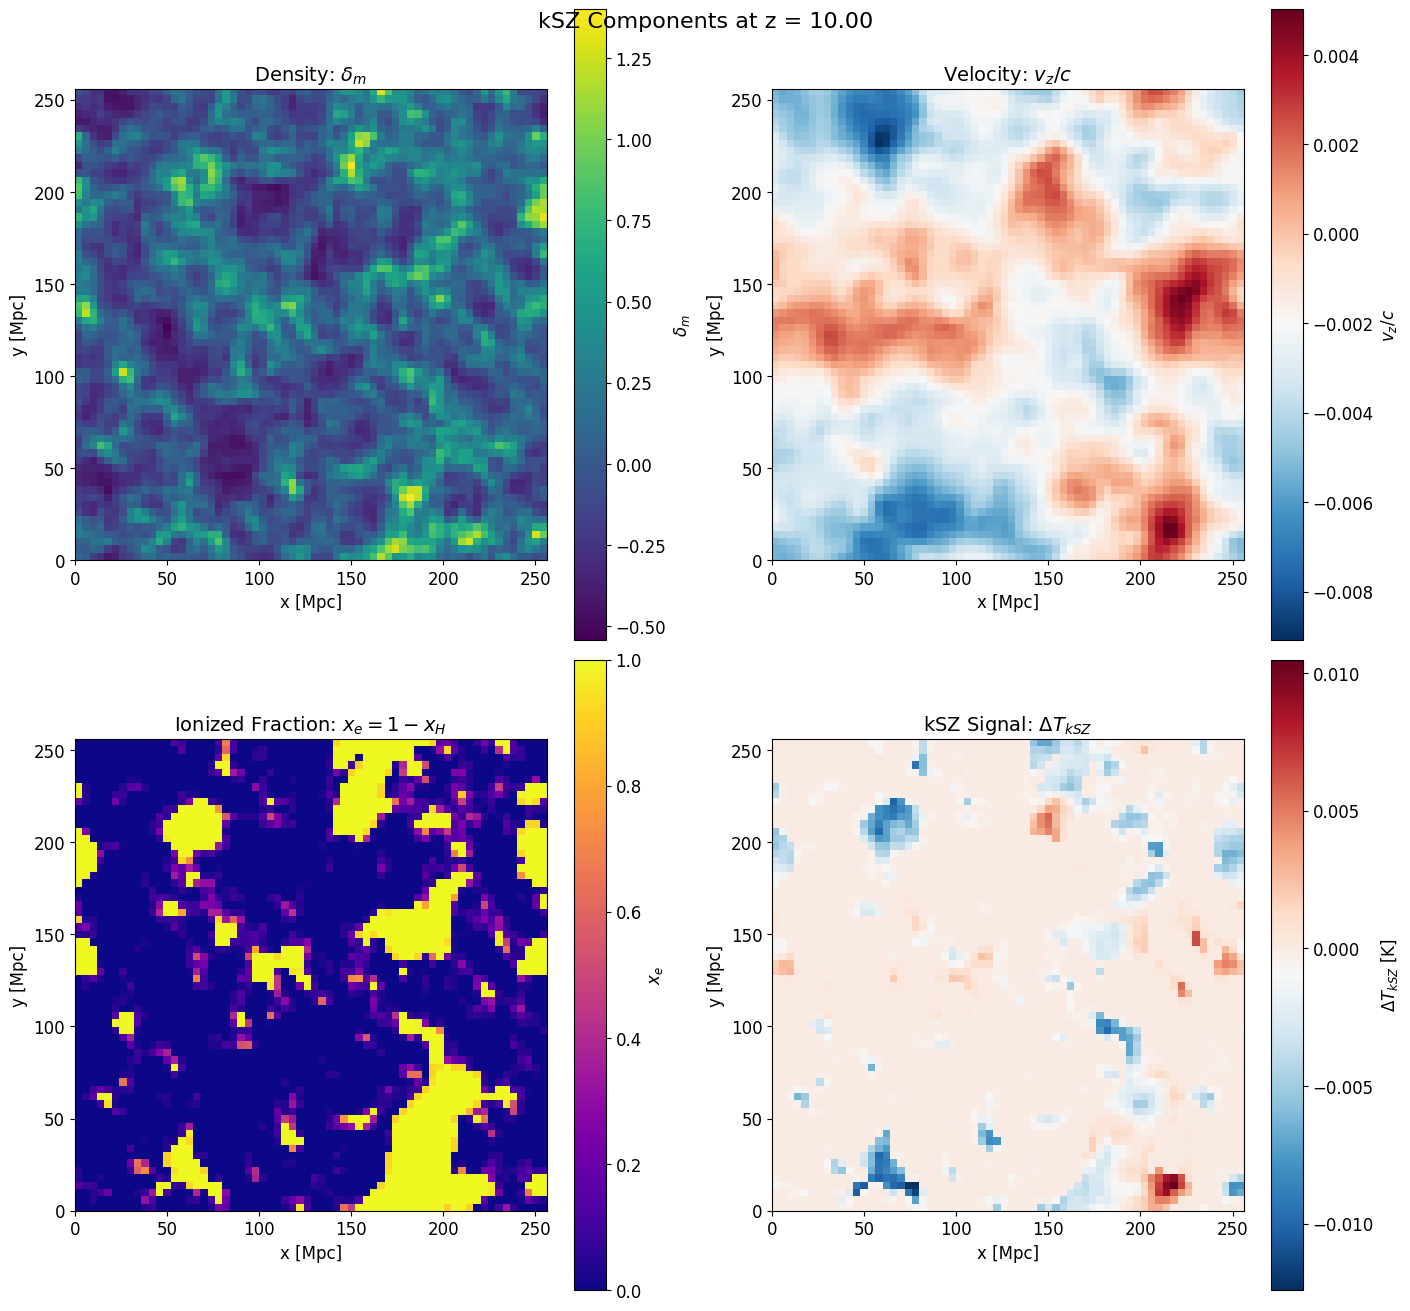


✓ Collage saved: kSZ_collage_z10.0.png

Field statistics at z = 10.001:
  δ_m:    mean=0.078, std=0.290
  v_z/c:  mean=-1.8552e-03, std=2.2410e-03
  x_e:    mean=0.205, std=0.371
  ΔT_kSZ: mean=-4.2366e-04 K, std=1.6461e-03 K


In [109]:
import numpy as np
import matplotlib.pyplot as plt

# Find the redshift slice closest to z=10
z_array = lcn.lc_redshifts
target_z = 10.0
z_idx = np.argmin(np.abs(z_array - target_z))
actual_z = z_array[z_idx]

print(f"Target redshift: {target_z}")
print(f"Closest slice: z = {actual_z:.3f} (index {z_idx})")

# Extract 2D slices at this redshift
density_slice = density[:, :, z_idx]
x_e_slice = x_e[:, :, z_idx]
v_over_c_slice = v_los_km_s[:, :, z_idx] / c_km_s
kSZ_slice = kSZ_uK[:, :, z_idx]

# Get the box size for axis labels
box_size = user_params.BOX_LEN  # Mpc

# Create the 2×2 collage
fig, axes = plt.subplots(2, 2, figsize=(14, 13), constrained_layout=True)

# 1. Density field (δ_m)
im1 = axes[0, 0].imshow(density_slice, 
                        origin='lower',
                        extent=[0, box_size, 0, box_size],
                        cmap='viridis',
                        interpolation='nearest')
axes[0, 0].set_xlabel('x [Mpc]', fontsize=12)
axes[0, 0].set_ylabel('y [Mpc]', fontsize=12)
axes[0, 0].set_title(r'Density: $\delta_m$', fontsize=14)
cbar1 = fig.colorbar(im1, ax=axes[0, 0])
cbar1.set_label(r'$\delta_m$', fontsize=12)

# 2. Velocity (v_z / c)
im2 = axes[0, 1].imshow(v_over_c_slice, 
                        origin='lower',
                        extent=[0, box_size, 0, box_size],
                        cmap='RdBu_r',
                        interpolation='nearest')
axes[0, 1].set_xlabel('x [Mpc]', fontsize=12)
axes[0, 1].set_ylabel('y [Mpc]', fontsize=12)
axes[0, 1].set_title(r'Velocity: $v_z / c$', fontsize=14)
cbar2 = fig.colorbar(im2, ax=axes[0, 1])
cbar2.set_label(r'$v_z / c$', fontsize=12)

# 3. Ionization fraction (x_e)
im3 = axes[1, 0].imshow(x_e_slice, 
                        origin='lower',
                        extent=[0, box_size, 0, box_size],
                        cmap='plasma',
                        interpolation='nearest',
                        vmin=0, vmax=1)
axes[1, 0].set_xlabel('x [Mpc]', fontsize=12)
axes[1, 0].set_ylabel('y [Mpc]', fontsize=12)
axes[1, 0].set_title(r'Ionized Fraction: $x_e = 1 - x_H$', fontsize=14)
cbar3 = fig.colorbar(im3, ax=axes[1, 0])
cbar3.set_label(r'$x_e$', fontsize=12)

# 4. kSZ signal (ΔT in μK)
im4 = axes[1, 1].imshow(kSZ_slice, 
                        origin='lower',
                        extent=[0, box_size, 0, box_size],
                        cmap='RdBu_r',
                        interpolation='nearest')
axes[1, 1].set_xlabel('x [Mpc]', fontsize=12)
axes[1, 1].set_ylabel('y [Mpc]', fontsize=12)
axes[1, 1].set_title(r'kSZ Signal: $\Delta T_{kSZ}$', fontsize=14)
cbar4 = fig.colorbar(im4, ax=axes[1, 1])
cbar4.set_label(r'$\Delta T_{kSZ}$ [K]', fontsize=12)

# Overall title
fig.suptitle(f'kSZ Components at z = {actual_z:.2f}', fontsize=16, y=0.995)

plt.savefig(f'kSZ_collage_z{actual_z:.1f}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Collage saved: kSZ_collage_z{actual_z:.1f}.png")

# Print statistics
print(f"\nField statistics at z = {actual_z:.3f}:")
print(f"  δ_m:    mean={density_slice.mean():.3f}, std={density_slice.std():.3f}")
print(f"  v_z/c:  mean={v_over_c_slice.mean():.4e}, std={v_over_c_slice.std():.4e}")
print(f"  x_e:    mean={x_e_slice.mean():.3f}, std={x_e_slice.std():.3f}")
print(f"  ΔT_kSZ: mean={kSZ_slice.mean():.4e} K, std={kSZ_slice.std():.4e} K")

In [127]:
import py21cmfast as p21c
from py21cmfast import plotting
import os
import matplotlib
matplotlib.use('Agg')  # Use non-interactive backend for cluster
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

print(f"21cmFAST version is {p21c.__version__}")
print(f"Starting run at {datetime.now()}")

# Create directory structure
output_dir = "v3_lightcones_20Nov"
cache_dir = os.path.join(output_dir, "_cache")
os.makedirs(cache_dir, exist_ok=True)
print(f"Output directory: {output_dir}")
print(f"Cache directory: {cache_dir}")

# Set up user parameters for 1 Gpc box with 512³ resolution
user_params = p21c.UserParams(
    HII_DIM=32, 
    BOX_LEN=50,  # 1 Gpc = 1000 Mpc
    KEEP_3D_VELOCITIES=True,
    USE_INTERPOLATION_TABLES=True  # Explicitly set to avoid warning
)

print(f"\nUser parameters:")
print(f"  HII_DIM: {user_params.HII_DIM}")
print(f"  BOX_LEN: {user_params.BOX_LEN} Mpc")
print(f"  Cell size: {user_params.cell_size} Mpc")

# Set up lightconer with velocity
lcn = p21c.RectilinearLightconer.with_equal_cdist_slices(
    min_redshift=7.0,
    max_redshift=12.0,
    quantities=('brightness_temp', 'density', 'velocity_z', 'xH_box'),
    resolution=user_params.cell_size,
    get_los_velocity=True,  # Enable LOS velocity
)

print(f"\nLightconer setup:")
print(f"  Redshift range: {lcn.lc_redshifts.min():.2f} - {lcn.lc_redshifts.max():.2f}")
print(f"  Number of slices: {len(lcn.lc_redshifts)}")
print(f"  get_los_velocity: True")

# Run lightcone (this will take a while!)
print(f"\nStarting lightcone calculation at {datetime.now()}")
print("This may take several hours for a 1 Gpc, 512³ box...")

lightcone = p21c.run_lightcone(
    lightconer=lcn,
    global_quantities=("brightness_temp", 'density', 'xH_box'),
    direc=cache_dir,
    user_params=user_params,
    write=True  # Write cache files
)

print(f"Lightcone calculation completed at {datetime.now()}")

# Check what fields are available
print("\nAvailable lightcone fields:")
for attr in dir(lightcone):
    if not attr.startswith('_') and hasattr(getattr(lightcone, attr), 'shape'):
        field = getattr(lightcone, attr)
        if hasattr(field, 'shape') and len(field.shape) == 3:
            print(f"  {attr}: {field.shape}")

# Save lightcone as HDF5
lightcone_file = os.path.join(output_dir, "lightcone_1Gpc_512.h5")
lightcone.save(lightcone_file)
print(f"\nLightcone saved to: {lightcone_file}")

# Create diagnostic plots
print("\nCreating diagnostic plots...")

# 1. Brightness temperature lightcone
fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plotting.lightcone_sliceplot(lightcone, 'brightness_temp', ax=ax, fig=fig)
plt.savefig(os.path.join(output_dir, 'brightness_temp_lightcone.png'), dpi=150, bbox_inches='tight')
plt.close()
print("  Saved: brightness_temp_lightcone.png")

# 2. Density lightcone
fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plotting.lightcone_sliceplot(lightcone, 'density', ax=ax, fig=fig)
plt.savefig(os.path.join(output_dir, 'density_lightcone.png'), dpi=150, bbox_inches='tight')
plt.close()
print("  Saved: density_lightcone.png")

# 3. xH_box lightcone
fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plotting.lightcone_sliceplot(lightcone, 'xH_box', ax=ax, fig=fig)
plt.savefig(os.path.join(output_dir, 'xH_lightcone.png'), dpi=150, bbox_inches='tight')
plt.close()
print("  Saved: xH_lightcone.png")

# 4. Velocity_z lightcone
if hasattr(lightcone, 'velocity_z'):
    fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
    plotting.lightcone_sliceplot(lightcone, 'velocity_z', ax=ax, fig=fig)
    plt.savefig(os.path.join(output_dir, 'velocity_z_lightcone.png'), dpi=150, bbox_inches='tight')
    plt.close()
    print("  Saved: velocity_z_lightcone.png")

# 5. LOS velocity lightcone (if available)
if hasattr(lightcone, 'los_velocity'):
    fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
    plotting.lightcone_sliceplot(lightcone, 'los_velocity', ax=ax, fig=fig)
    plt.savefig(os.path.join(output_dir, 'los_velocity_lightcone.png'), dpi=150, bbox_inches='tight')
    plt.close()
    print("  Saved: los_velocity_lightcone.png")

# 6. kSZ product field
print("\nCalculating kSZ product field...")
density = lightcone.density
xH = lightcone.xH_box
x_e = 1.0 - xH

# Get velocity (check which field is available)
if hasattr(lightcone, 'los_velocity'):
    v_los = lightcone.los_velocity
elif hasattr(lightcone, 'velocity_z'):
    v_los = lightcone.velocity_z
else:
    print("  Warning: No velocity field found!")
    v_los = None

if v_los is not None:
    # Convert velocity from Mpc/s to km/s
    Mpc_to_km = 3.086e19
    v_los_km_s = v_los * Mpc_to_km
    c_km_s = 3e5
    
    # kSZ in μK
    T_CMB_uK = 2.7255e6
    kSZ_uK = (1 + density) * x_e * v_los_km_s / c_km_s * T_CMB_uK
    
    # Add to lightcone
    lightcone.kSZ_uK = kSZ_uK
    
    # Plot kSZ
    fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
    plotting.lightcone_sliceplot(lightcone, 'kSZ_uK', ax=ax, fig=fig)
    plt.savefig(os.path.join(output_dir, 'kSZ_lightcone.png'), dpi=150, bbox_inches='tight')
    plt.close()
    print("  Saved: kSZ_lightcone.png")

print(f"\nAll done at {datetime.now()}!")
print(f"Output files saved in: {output_dir}/")

21cmFAST version is 3.4.0
Starting run at 2025-11-20 14:16:36.123286
Output directory: v3_lightcones_20Nov
Cache directory: v3_lightcones_20Nov/_cache

User parameters:
  HII_DIM: 32
  BOX_LEN: 50 Mpc
  Cell size: 1.5625 Mpc Mpc

Lightconer setup:
  Redshift range: 7.00 - 12.00
  Number of slices: 774
  get_los_velocity: True

Starting lightcone calculation at 2025-11-20 14:16:37.116246
This may take several hours for a 1 Gpc, 512³ box...
Lightcone calculation completed at 2025-11-20 14:16:51.588448

Available lightcone fields:
  brightness_temp: (32, 32, 774)
  density: (32, 32, 774)


/home/swanith/.local/lib/python3.10/site-packages/py21cmfast/outputs.py:1185: UserWarning: global_xHI is deprecated. From now on, use global_xH. Will be removed in v3.1
  warnings.warn(


  los_velocity: (32, 32, 774)
  velocity_z: (32, 32, 774)
  xH_box: (32, 32, 774)

Lightcone saved to: v3_lightcones_20Nov/lightcone_1Gpc_512.h5

Creating diagnostic plots...
  Saved: brightness_temp_lightcone.png
  Saved: density_lightcone.png
  Saved: xH_lightcone.png
  Saved: velocity_z_lightcone.png
  Saved: los_velocity_lightcone.png

Calculating kSZ product field...
  Saved: kSZ_lightcone.png

All done at 2025-11-20 14:17:04.805532!
Output files saved in: v3_lightcones_20Nov/


In [132]:
import os
import socket

print(f"Hostname: {socket.gethostname()}")
print(f"Display variable: {os.environ.get('DISPLAY', 'NOT SET')}")

# Check if in notebook
try:
    get_ipython()
    print("Environment: Jupyter/IPython notebook")
except NameError:
    print("Environment: Regular Python script")

Hostname: usha
Display variable: :1
Environment: Jupyter/IPython notebook
